## func

In [2]:
import numpy as np
import scipy.signal as sig
from scipy.io import wavfile
import matplotlib.pyplot as plt
import sounddevice as sd

fs = 44100  # Hz

def gent(dur_sec, fs=44100):
    return np.linspace(0, dur_sec, int(dur_sec * fs), endpoint=False)

def sin(t, f):
    return np.sin(2 * np.pi * f * t)

def sqr(t, f):
    return np.sign(np.sin(2 * np.pi * f * t))

def tri(t, f):
    return 2 * np.abs(2 * (t * f % 1) - 1) - 1

def saw(t, f):
    return 2 * (f * t % 1) - 1

def white_noise(t):
    return np.random.uniform(-1, 1, len(t))

def pink_noise(t):
    # Voss-McCartneyアルゴリズム
    N = len(t)
    rows = 64  # 精度を上げたい場合は増やす
    array = np.random.randn(rows, N)
    array = np.cumsum(array, axis=1)
    noise = np.sum(array, axis=0)
    noise = noise / np.max(np.abs(noise))  # 正規化
    return noise

def EG_ADSR(t, sample_rate, attack=0.1, decay=0.2, sustain=0.7, release=0.5):
    env = np.zeros_like(t)
    N = len(t)
    A = int(attack * sample_rate)
    D = int(decay * sample_rate)
    R = int(release * sample_rate)
    S = N - (A + D + R)

    if A > 0:
        env[:A] = np.linspace(0, 1, A)
    if D > 0:
        env[A:A+D] = np.linspace(1, sustain, D)
    if S > 0:
        env[A+D:A+D+S] = sustain
    if R > 0:
        env[A+D+S:] = np.linspace(sustain, 0, R)
    return env

def show_waveform(t, wave):
    plt.plot(t[:], wave[:], color='b')
    plt.title('Wave Form')
    plt.xlabel('Time [s]')
    plt.ylabel('Amplitude')
    plt.grid()
    plt.show()

def show_one(t, wave):
    pass

def show_spc(wave, fs, log=False):
    fft = np.fft.fft(wave)
    freqs = np.fft.fftfreq(len(fft), 1/fs)
    # 片側スペクトルだけ取り出し
    half = len(fft)//2
    plt.figure(figsize=(8,4))
    plt.plot(freqs[:half], np.abs(fft[:half]))
    if log:
        plt.xscale("log")
    plt.xlabel("Frequency [Hz]")
    plt.ylabel("Amplitude Spectrum")
    plt.title("Spectrum of the Waveform")
    plt.grid()
    plt.show()

def show_psd(wave, fs, log=False):
    f, Pxx = sig.welch(wave, fs=fs, nperseg=1024)
    plt.figure(figsize=(8,4))
    plt.semilogy(f, Pxx)  # 対数表示にすると見やすい
    if log:
        plt.xscale("log")
    plt.xlabel("Frequency [Hz]")
    plt.ylabel("Power Spectral Density")
    plt.title("Power Spectral Density (Welch Method)")
    plt.grid()
    plt.show()

def play(wave, fs):
    sd.play(wave, fs)
    sd.wait()

def load_wav(path):
    fs, wave = wavfile.read(path)  # fs: サンプリング周波数, wave: ndarray
    # int16 など整数型の場合は [-1, 1] に正規化するのが一般的
    if wave.dtype != np.float32 and wave.dtype != np.float64:
        wave = wave.astype(np.float32) / np.iinfo(wave.dtype).max
    if wave.ndim > 1:
        wave = wave.mean(axis=1)  # モノラル化
    return fs, wave


In [ ]:
fs = 44100
duration_sec = 101

t = gent(duration_sec, fs)

f_list = [
    528 * (2**(-2/2)),
    528 * (2**(-1/2)),
    528 * (2**(-0/2)),
    528 * (2**(1/2)),
]

for f in f_list:
    t_tmp = gent()



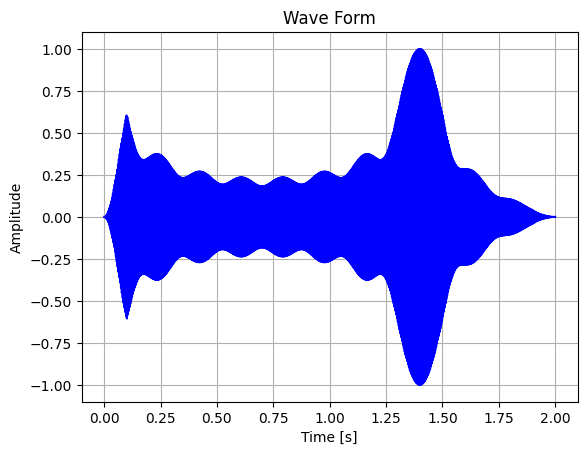

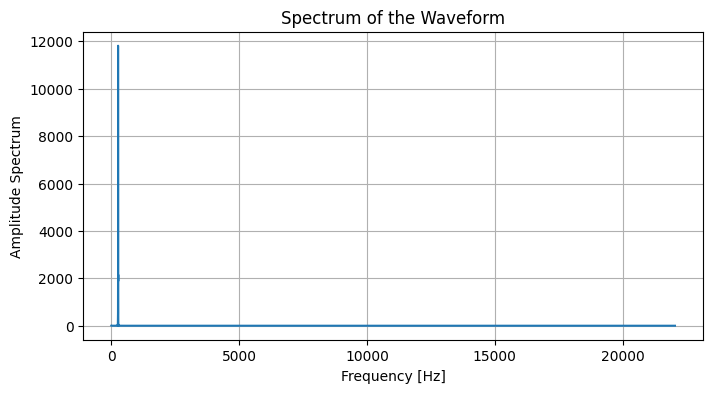

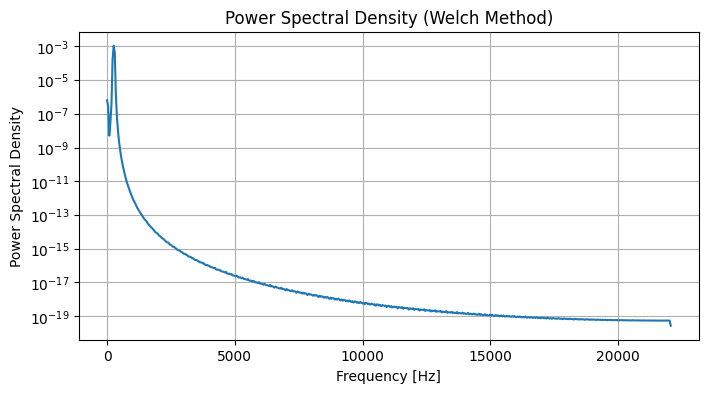

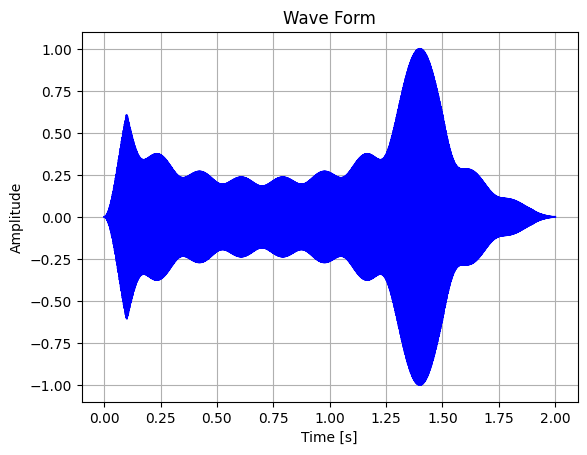

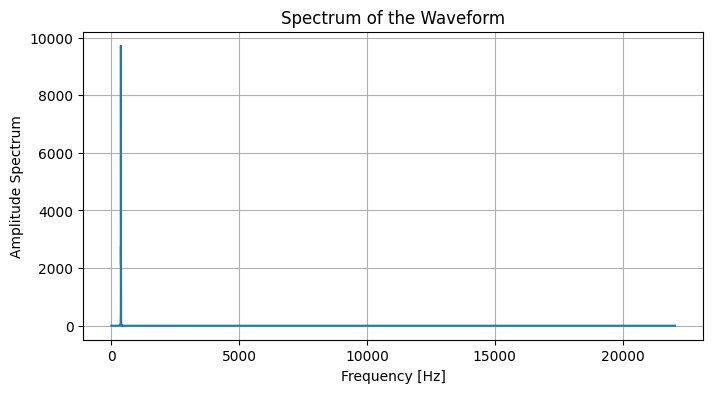

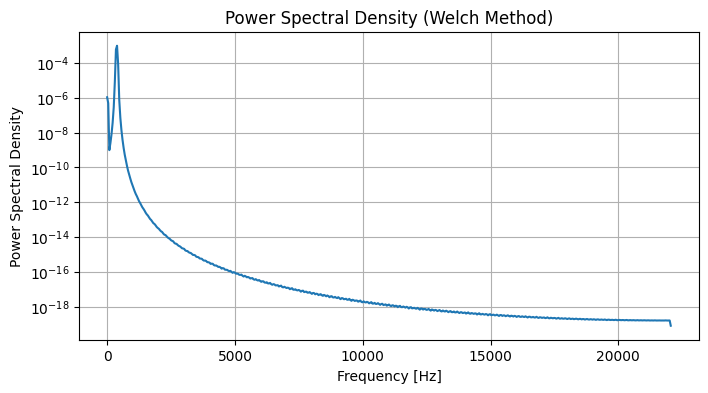

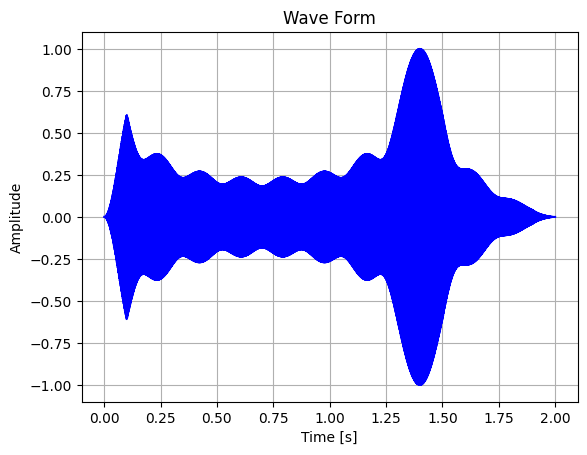

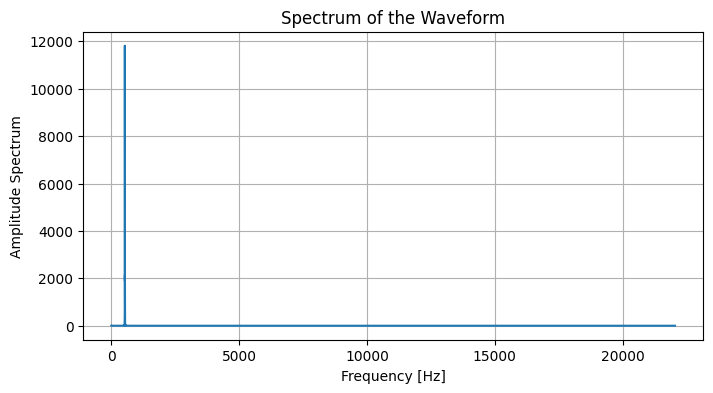

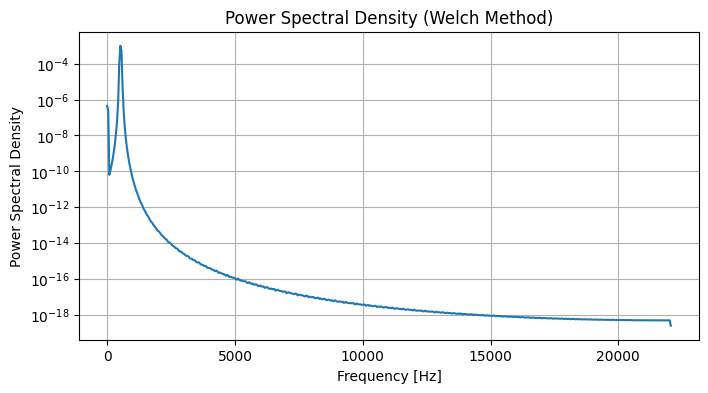

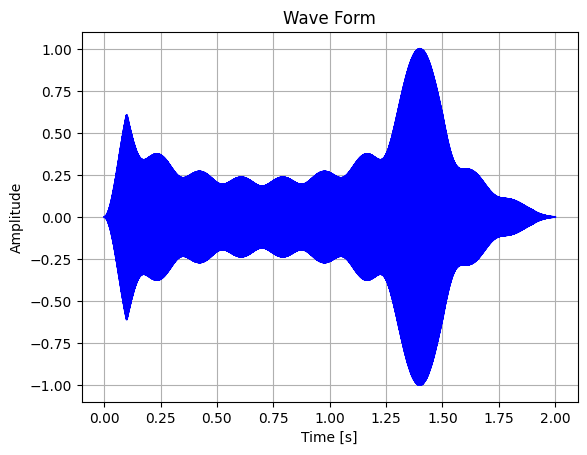

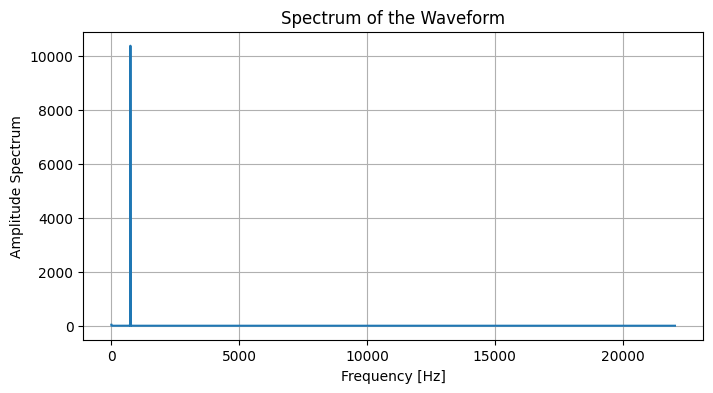

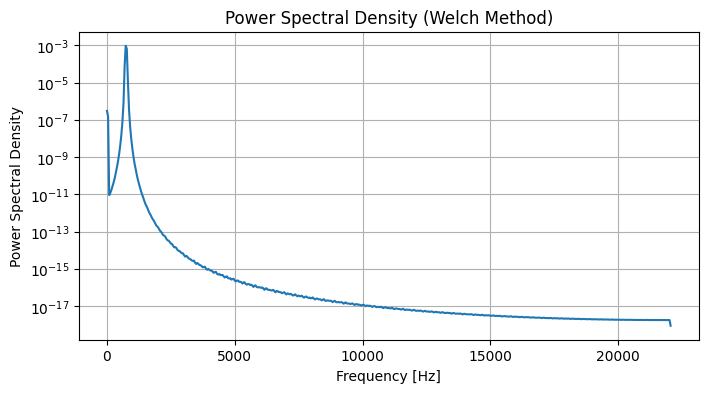

In [ ]:
fs = 44100
duration_sec = 2

t = gent(duration_sec, fs=fs)

f0 = 528 * (2**(-2/2))
f1 = 528 * (2**(-1/2))
f2 = 528 * (2**(-0/2))
f3 = 528 * (2**(1/2))

for f in [f0, f1, f2, f3]:
    w = sin(t, f)
    ws = [1/f/(n+1) * sin(t, f+n) for n in np.linspace(0, 5, 8)]
    w = np.array(ws).sum(axis=0)
    env = EG_ADSR(t, fs, 0.1, 0, 1, 0.5)
    w *= env
    env_fade = EG_ADSR(t, fs, 0.1, 0, 1, 0.1)
    w *= env_fade

    w = 2 * (w - np.min(w)) / (np.max(w) - np.min(w)) - 1

    show_waveform(t, w)
    show_spc(w, fs=fs)
    show_psd(w, fs=fs)
    play(w, fs=fs)